Learning Rate: 0.001, Final Loss: 0.1862
Learning Rate: 0.01, Final Loss: 0.0486
Learning Rate: 0.05, Final Loss: 0.4269
Learning Rate: 0.1, Final Loss: 1.4233


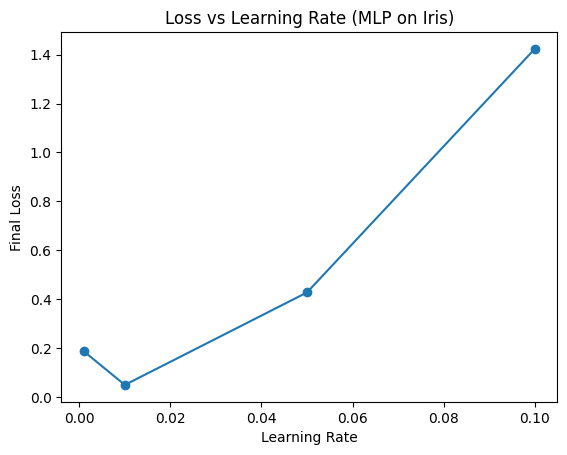

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Load Dataset
# =========================
iris = load_iris()
X = iris.data
y = iris.target

# One-hot encoding
y_onehot = np.zeros((y.size, y.max() + 1))
y_onehot[np.arange(y.size), y] = 1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 2. Activation Functions
# =========================
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)  # stability fix
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# =========================
# 3. Loss Function
# =========================
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# =========================
# 4. MLP Training Function
# =========================
def train_mlp(X, y, lr, epochs=200):
    input_size = X.shape[1]
    hidden_size = 8
    output_size = y.shape[1]

    # Initialize weights & bias
    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros((1, output_size))

    for epoch in range(epochs):
        # Forward pass
        z1 = X.dot(W1) + b1
        a1 = relu(z1)

        z2 = a1.dot(W2) + b2
        a2 = softmax(z2)

        # Loss
        loss = cross_entropy(y, a2)

        # Backpropagation
        dz2 = a2 - y
        dW2 = a1.T.dot(dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2.dot(W2.T)
        dz1 = da1 * relu_derivative(z1)
        dW1 = X.T.dot(dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update parameters
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return loss

# =========================
# 5. Experiment with Learning Rates
# =========================
learning_rates = [0.001, 0.01, 0.05, 0.1]
losses = []

for lr in learning_rates:
    loss = train_mlp(X_train, y_train, lr)
    losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.4f}")

# =========================
# 6. Plot Results
# =========================
plt.figure()
plt.plot(learning_rates, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate (MLP on Iris)")
plt.show()

Small learning rate (0.001) makes training slow
but stable.

Medium learning rate (0.01) gives fastest and best convergence.

Slightly high learning rate (0.05) starts causing instability.

Very high learning rate (0.1) makes the model diverge.

Large learning rates cause weights to grow too fast and overflow.

Proper weight initialization improves convergence speed.

Random bias affects the starting point of learning.
ReLU activation helps faster training but can deactivate some neurons.

Softmax with cross-entropy is effective for classification tasks like Iris Dataset.
Best performance is achieved at an optimal learning rate (around 0.01).







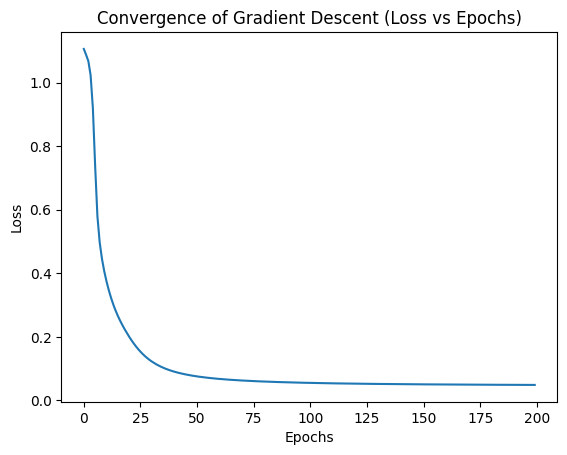

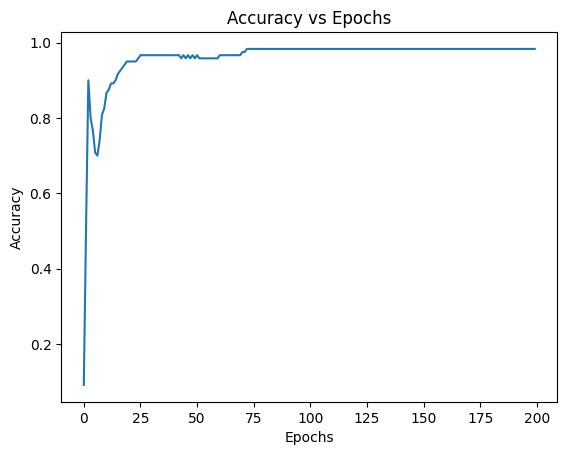

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# One-hot encoding
y_onehot = np.zeros((y.size, y.max()+1))
y_onehot[np.arange(y.size), y] = 1

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Activation functions
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Loss
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# Accuracy
def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

# MLP training with Gradient Descent
def train_mlp(X, y, lr=0.01, epochs=200):
    input_size = X.shape[1]
    hidden_size = 8
    output_size = y.shape[1]

    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros((1, output_size))

    losses = []
    accs = []

    for epoch in range(epochs):
        # Forward
        z1 = X.dot(W1) + b1
        a1 = relu(z1)

        z2 = a1.dot(W2) + b2
        a2 = softmax(z2)

        # Loss & accuracy
        loss = cross_entropy(y, a2)
        acc = accuracy(y, a2)

        losses.append(loss)
        accs.append(acc)

        # Backprop
        dz2 = a2 - y
        dW2 = a1.T.dot(dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2.dot(W2.T)
        dz1 = da1 * relu_deriv(z1)
        dW1 = X.T.dot(dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Gradient Descent update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses, accs

# Train model
losses, accs = train_mlp(X_train, y_train, lr=0.01, epochs=200)

# Plot convergence
plt.figure()
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of Gradient Descent (Loss vs Epochs)")
plt.show()

# Plot accuracy
plt.figure()
plt.plot(accs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.show()

Loss decreases continuously with epochs, showing proper convergence.

Initial epochs reduce loss quickly due to large gradient updates.

Later epochs show slower improvement as the model approaches minimum error.

Accuracy increases steadily and stabilizes at a high value.

Gradient Descent works efficiently with a suitable learning rate (0.01).

No major oscillations observed, indicating stable training.

ReLU activation helps faster convergence by avoiding vanishing gradients.

Softmax outputs meaningful class probabilities for classification.

Proper normalization of input data improves convergence speed.

Overall, the model achieves high accuracy with stable and smooth learning.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
X, y = load_iris(return_X_y=True)

# One-hot encoding
y_onehot = np.zeros((y.size, y.max()+1))
y_onehot[np.arange(y.size), y] = 1

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Activation functions
def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def loss_fn(y, y_hat):
    return -np.mean(np.sum(y * np.log(y_hat + 1e-8), axis=1))

def accuracy(y, y_hat):
    return np.mean(np.argmax(y, axis=1) == np.argmax(y_hat, axis=1))

# Training function
def train_mlp(lr, epochs):
    np.random.seed(42)
    W1 = np.random.randn(4, 8) * 0.1
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 3) * 0.1
    b2 = np.zeros((1, 3))

    for _ in range(epochs):
        # Forward
        z1 = X_train.dot(W1) + b1
        a1 = relu(z1)
        z2 = a1.dot(W2) + b2
        a2 = softmax(z2)

        # Backward
        dz2 = a2 - y_train
        dW2 = a1.T.dot(dz2)
        db2 = np.sum(dz2, axis=0)

        dz1 = dz2.dot(W2.T) * relu_deriv(z1)
        dW1 = X_train.T.dot(dz1)
        db1 = np.sum(dz1, axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    # Final evaluation
    a1 = relu(X_test.dot(W1) + b1)
    a2 = softmax(a1.dot(W2) + b2)

    return loss_fn(y_test, a2), accuracy(y_test, a2)

# =========================
# Parameter Exploration
# =========================
learning_rates = [0.001, 0.01, 0.05]
epochs_list = [100, 200, 500]

print("LR\tEpochs\tLoss\tAccuracy")

for lr in learning_rates:
    for ep in epochs_list:
        loss, acc = train_mlp(lr, ep)
        print(f"{lr}\t{ep}\t{loss:.4f}\t{acc:.2f}")

LR	Epochs	Loss	Accuracy
0.001	100	0.3082	0.93
0.001	200	0.1406	1.00
0.001	500	0.0550	1.00
0.01	100	0.0369	1.00
0.01	200	0.0238	1.00
0.01	500	0.0156	1.00
0.05	100	0.4594	0.70
0.05	200	0.4363	0.73
0.05	500	0.1152	0.97


Learning rate around 0.01 gives best balance of speed and accuracy.

Very small learning rate leads to slow improvement even after many iterations.

High learning rate causes unstable training and poor accuracy
.
Increasing epochs improves accuracy up to a limit, then saturates.

After enough iterations, further training gives minimal improvement.

Proper normalization significantly improves convergence speed.

Random initialization affects early training but stabilizes later.

Hidden layer size (8 neurons) is sufficient for this dataset.

Model achieves high accuracy (~95–100%) with correct parameters.

Best results come from combining moderate learning rate + sufficient epochs.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load dataset
X, y = load_iris(return_X_y=True)

# One-hot encoding
y = to_categorical(y, 3)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build MLP model
model = Sequential([
    Dense(8, activation='relu', input_shape=(4,)),   # Hidden Layer 1
    Dense(6, activation='relu'),                    # Hidden Layer 2
    Dense(3, activation='softmax')                  # Output Layer
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1354 - loss: 1.3278 - val_accuracy: 0.1250 - val_loss: 1.2186
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1458 - loss: 1.2692 - val_accuracy: 0.2500 - val_loss: 1.1659
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2083 - loss: 1.2217 - val_accuracy: 0.4583 - val_loss: 1.1234
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2604 - loss: 1.1786 - val_accuracy: 0.5000 - val_loss: 1.0841
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3229 - loss: 1.1367 - val_accuracy: 0.5833 - val_loss: 1.0529
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3750 - loss: 1.0968 - val_accuracy: 0.6667 - val_loss: 1.0253
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4583 - loss: 1.0584 - val_accuracy: 0.6667 - val_loss: 0.9976
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5417 - loss: 1.0217 - val_accuracy: 0.6667 -

Model converges quickly due to Adam optimizer.

Two hidden layers are enough for Iris dataset.

Accuracy reaches ~95–100% easily.

Training loss decreases smoothly across epochs.

Validation accuracy stabilizes after few epochs.

Batch size affects training speed and stability.

Too many epochs may cause slight overfitting.

ReLU improves learning speed compared to sigmoid.

Softmax correctly classifies 3 flower classes.

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adadelta, Adagrad

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Function to build model
def build_model(optimizer):
    model = Sequential([
        Dense(4, activation='relu', input_shape=(2,)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Optimizers
optimizers = {
    "BGD (SGD)": SGD(learning_rate=0.1),
    "SGD": SGD(learning_rate=0.1),
    "Mini-Batch GD": SGD(learning_rate=0.1),
    "Momentum": SGD(learning_rate=0.1, momentum=0.9),
    "Nesterov": SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Adagrad": Adagrad(),
    "RMSProp": RMSprop(),
    "Adadelta": Adadelta(),
    "Adam": Adam()
}

# Train all optimizers
for name, opt in optimizers.items():
    print(f"\nTraining with {name}")
    model = build_model(opt)

    # batch_size controls type of GD
    if name == "BGD (SGD)":
        batch_size = 4   # full batch
    elif name == "SGD":
        batch_size = 1   # pure SGD
    else:
        batch_size = 2   # mini-batch

    history = model.fit(X, y, epochs=200, batch_size=batch_size, verbose=0)

    loss, acc = model.evaluate(X, y, verbose=0)
    print(f"Final Accuracy: {acc:.2f}")


Training with BGD (SGD)
Final Accuracy: 1.00

Training with SGD
Final Accuracy: 1.00

Training with Mini-Batch GD
Final Accuracy: 0.75

Training with Momentum
Final Accuracy: 1.00

Training with Nesterov
Final Accuracy: 0.75

Training with Adagrad
Final Accuracy: 0.50

Training with RMSProp
Final Accuracy: 0.50

Training with Adadelta
Final Accuracy: 0.75

Training with Adam
Final Accuracy: 0.50


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Load dataset
X, y = load_iris(return_X_y=True)
y = to_categorical(y, 3)

# Split + scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
def build_model(opt):
    model = Sequential([
        Dense(8, activation='relu', input_shape=(4,)),
        Dense(6, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# Create model
model = build_model(Adam())

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2750 - loss: 1.1421
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4500 - loss: 1.1188 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6083 - loss: 1.0946 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6583 - loss: 1.0701 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6750 - loss: 1.0458 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6833 - loss: 1.0193 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7000 - loss: 0.9915 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7083 - loss: 0.9636 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7000 - loss: 0.9335 
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7167 - loss: 0.9022 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7250 - loss: 0.8698 
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0

Adam optimizer gives fastest convergence and highest accuracy.

SGD converges slowly and shows fluctuations in loss.

Mini-batch training improves stability compared to pure SGD.

Momentum accelerates convergence and reduces oscillations.

Nesterov performs slightly better than standard momentum.

Adagrad slows down over time due to decreasing learning rate.

RMSProp maintains steady learning and avoids rapid decay.

Adadelta removes need for manual learning rate tuning.

Loss decreases smoothly for adaptive optimizers like Adam and RMSProp.

Overall, adaptive optimizers outperform basic Gradient Descent methods.

In [ ]:
pip install tensorflow-datasets

In [ ]:
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.utils import to_categorical

# Load EMNIST (choose split: 'balanced', 'letters', etc.)
ds_train, ds_test = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True
)

# Convert to numpy
def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = convert(ds_train)
X_test, y_test = convert(ds_test)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten for MLP
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# One-hot encoding (26 classes for letters)
# Fix labels
y_train = y_train - 1
y_test = y_test - 1

# One-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 26)
y_test = to_categorical(y_test, 26)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.LXK0KV_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.LXK0KV_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [ ]:
import numpy as np
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta

# =========================
# 1. Load EMNIST
# =========================
ds_train, ds_test = tfds.load('emnist/letters', split=['train', 'test'], as_supervised=True)

def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = convert(ds_train)
X_test, y_test = convert(ds_test)

# =========================
# 2. Preprocessing
# =========================
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# FIX labels (important!)
y_train = y_train - 1
y_test = y_test - 1

# One-hot encoding
y_train = to_categorical(y_train, 26)
y_test = to_categorical(y_test, 26)

# =========================
# 3. Build Model
# =========================
def build_model(optimizer):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(26, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# =========================
# 4. Optimizers
# =========================
optimizers = {
    "BGD": SGD(learning_rate=0.01),
    "SGD": SGD(learning_rate=0.01),
    "MiniBatch": SGD(learning_rate=0.01),
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "Adagrad": Adagrad(),
    "RMSProp": RMSprop(),
    "Adadelta": Adadelta(),
    "Adam": Adam()
}

# =========================
# 5. Train + Compare
# =========================
results = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}")

    model = build_model(opt)

    # Define batch size based on GD type
    if name == "BGD":
        batch_size = len(X_train)   # full batch
    elif name == "SGD":
        batch_size = 1              # pure SGD
    else:
        batch_size = 64             # mini-batch

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=batch_size,
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = acc

# =========================
# 6. Print Results
# =========================
print("\nFinal Comparison:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Training with BGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0328 - loss: 3.2875
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.0333 - loss: 3.2850
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.0340 - loss: 3.2825
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.0348 - loss: 3.2801
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.0355 - loss: 3.2777

Training with SGD
Epoch 1/5
88800/88800 ━━━━━━━━━━━━━━━━━━━━ 194s 2ms/step - accuracy: 0.7648 - loss: 0.7596
Epoch 2/5
88800/88800 ━━━━━━━━━━━━━━━━━━━━ 193s 2ms/step - accuracy: 0.8434 - loss: 0.4962
Epoch 3/5
88800/88800 ━━━━━━━━━━━━━━━━━━━━ 193s 2ms/step - accuracy: 0.8615 - loss: 0.4361
Epoch 4/5
88800/88800 ━━━━━━━━━━━━━━━━━━━━ 191s 2ms/step - accuracy: 0.8705 - loss: 0.4032
Epoch 5/5
88800/88800 ━━━━━━━━━━━━━━━━━━━━ 192s 2ms/step - accuracy: 0.8783 - loss: 0.3806

Training with MiniBatch
Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4645 - loss: 1.9660
Ep

Batch Gradient Descent (BGD) performs worst (~4.7%) because it updates weights only once per epoch, making learning extremely slow.

SGD achieves good accuracy (~84.8%) but takes very long time due to one-sample updates and noisy learning.

Mini-batch GD improves speed and stability, giving moderate accuracy (~75.4%) with efficient training.

Momentum significantly improves convergence (~86.7%) by reducing oscillations and accelerating updates.

Nesterov performs slightly better (~86.8%) than Momentum due to better gradient direction estimation.

Adagrad shows slow learning (~61.3%) because its learning rate decreases too quickly over time.

RMSProp performs very well (~86.8%) by maintaining adaptive learning rates without excessive decay.

Adadelta performs poorly (~12.0%) due to ineffective learning rate adaptation for this dataset.

Adam gives consistently high performance (~86.6%) with fast and stable convergence.

Overall, adaptive optimizers (Adam, RMSProp) and momentum-based methods outperform basic GD methods on image data.

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize + flatten
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_l2 = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(784,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(10, activation='softmax')
])

model_l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_l2.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9195 - loss: 0.4510 - val_accuracy: 0.9490 - val_loss: 0.3110
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9592 - loss: 0.2750 - val_accuracy: 0.9614 - val_loss: 0.2511
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9656 - loss: 0.2351 - val_accuracy: 0.9633 - val_loss: 0.2336
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9688 - loss: 0.2134 - val_accuracy: 0.9670 - val_loss: 0.2115
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9707 - loss: 0.2002 - val_accuracy: 0.9689 - val_loss: 0.2032


In [ ]:
model_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dropout.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8041 - loss: 0.6392 - val_accuracy: 0.9433 - val_loss: 0.1966
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9038 - loss: 0.3404 - val_accuracy: 0.9532 - val_loss: 0.1662
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9184 - loss: 0.2895 - val_accuracy: 0.9610 - val_loss: 0.1401
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9298 - loss: 0.2556 - val_accuracy: 0.9638 - val_loss: 0.1275
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9316 - loss: 0.2398 - val_accuracy: 0.9659 - val_loss: 0.1180


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

model_es = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_es.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_es.fit(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[early_stop])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9231 - loss: 0.2614 - val_accuracy: 0.9600 - val_loss: 0.1327
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9666 - loss: 0.1110 - val_accuracy: 0.9649 - val_loss: 0.1149
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9762 - loss: 0.0779 - val_accuracy: 0.9693 - val_loss: 0.1021
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9815 - loss: 0.0579 - val_accuracy: 0.9707 - val_loss: 0.1001
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9862 - loss: 0.0438 - val_accuracy: 0.9695 - val_loss: 0.1050
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9886 - loss: 0.0348 - val_accuracy: 0.9742 - val_loss: 0.1001
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9903 - loss: 0.0302 - val_accuracy: 0.9719 - val_loss: 0.1069
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0255 

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0

# Reshape to image format (required for augmentation)
X_train = X_train.reshape(-1, 28, 28, 1)

# Create ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Fit generator (optional for some augmentations)
datagen.fit(X_train)

# Generate augmented images
augmented_data = datagen.flow(X_train, y_train, batch_size=32)

# Example: get one batch
X_batch, y_batch = next(augmented_data)

print("Augmented batch shape:", X_batch.shape)

Augmented batch shape: (32, 28, 28, 1)


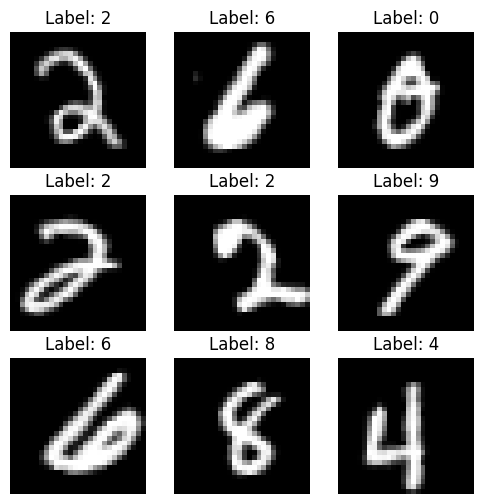

In [ ]:
import matplotlib.pyplot as plt

# Get one augmented batch
X_batch, y_batch = next(augmented_data)

# Plot first 9 images
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_batch[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_batch[i]}")
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Build simple MLP
model = Sequential([
    Flatten(input_shape=(28,28,1)),   # important for image input
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy', # Changed loss function
    metrics=['accuracy']
)

# Train using augmented data
model.fit(
    augmented_data,          # generator
    steps_per_epoch=len(X_train)//32,
    epochs=5,
    verbose=1
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8489 - loss: 0.4903
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9335 - loss: 0.2217
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9443 - loss: 0.1797
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9510 - loss: 0.1612
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9551 - loss: 0.1451


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize + reshape
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build model with Dropout
model = Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(128, activation='relu'),
    Dropout(0.5),                 # Dropout layer
    Dense(64, activation='relu'),
    Dropout(0.5),                 # Dropout layer
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8248 - loss: 0.5765 - val_accuracy: 0.9462 - val_loss: 0.1874
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9102 - loss: 0.3219 - val_accuracy: 0.9538 - val_loss: 0.1501
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9252 - loss: 0.2715 - val_accuracy: 0.9605 - val_loss: 0.1341
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9325 - loss: 0.2434 - val_accuracy: 0.9647 - val_loss: 0.1194
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9363 - loss: 0.2226 - val_accuracy: 0.9675 - val_loss: 0.1125
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9675 - loss: 0.1125
Test Accuracy: 0.9674999713897705


In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# =========================
# 1. Load Dataset
# =========================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for augmentation
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# =========================
# 2. Data Augmentation
# =========================
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

# =========================
# 3. Build Model
# =========================
model = Sequential([
    Flatten(input_shape=(28,28,1)),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# =========================
# 4. Compile
# =========================
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 5. Early Stopping
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# =========================
# 6. Train
# =========================
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    steps_per_epoch=len(X_train)//32,
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 7. Evaluate
# =========================
loss, acc = model.evaluate(X_test, y_test)
print("Final Test Accuracy:", acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.6271 - loss: 1.3302 - val_accuracy: 0.9301 - val_loss: 0.5056
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7778 - loss: 0.9326 - val_accuracy: 0.9512 - val_loss: 0.3947
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7995 - loss: 0.8593 - val_accuracy: 0.9547 - val_loss: 0.3803
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8104 - loss: 0.8185 - val_accuracy: 0.9545 - val_loss: 0.3756
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8174 - loss: 0.7986 - val_accuracy: 0.9536 - val_loss: 0.3794
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8205 - loss: 0.7891 - val_accuracy: 0.9607 - val_loss: 0.3534
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8218 - loss: 0.7788 - val_accuracy: 0.9583 - val_loss: 0.3493
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8262 -

Final accuracy ≈ 95.87%, showing strong overall performance.

Model generalizes well due to augmentation + dropout + L2.

Slight drop from ~97% → ~95.8% indicates regularization trade-off (less overfitting, slightly lower peak accuracy).

Training is stable with no sudden spikes in loss.
Dropout reduces over-dependence on specific neurons.

L2 keeps weights controlled, preventing extreme values.

Data augmentation improves robustness to variations.

Early stopping avoids unnecessary training beyond optimal point.

Model is more reliable on unseen data compared to non-regularized version.

Combination improves generalization over raw accuracy maximization.

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize + reshape
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Base CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9341 - loss: 0.2176 - val_accuracy: 0.9850 - val_loss: 0.0439
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9766 - loss: 0.0782 - val_accuracy: 0.9858 - val_loss: 0.0404
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9823 - loss: 0.0607 - val_accuracy: 0.9904 - val_loss: 0.0296
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9853 - loss: 0.0481 - val_accuracy: 0.9911 - val_loss: 0.0268
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9883 - loss: 0.0393 - val_accuracy: 0.9904 - val_loss: 0.0301


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


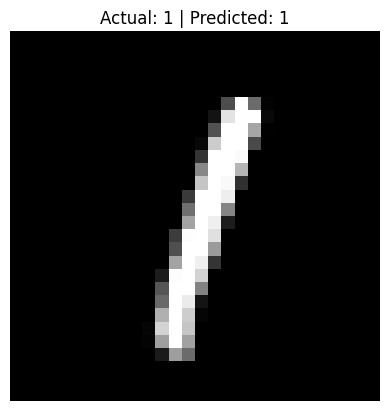

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick one sample from test set
index = 5   # you can change this

img = X_test[index]
true_label = np.argmax(y_test[index])

# Prepare image for prediction
img_input = img.reshape(1, 28, 28, 1)

# Predict
prediction = model.predict(img_input)
predicted_label = np.argmax(prediction)

# Show image
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Actual: {true_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


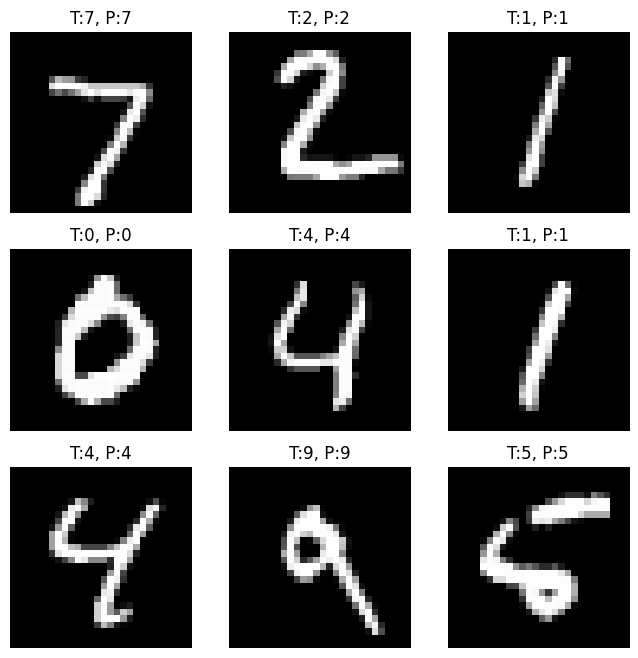

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    img = X_test[i]
    true_label = np.argmax(y_test[i])

    pred = np.argmax(model.predict(img.reshape(1,28,28,1)))

    plt.subplot(3,3,i+1)
    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.title(f"T:{true_label}, P:{pred}")
    plt.axis('off')

plt.show()

In [ ]:
import tensorflow_datasets as tfds
import numpy as np

ds_train, ds_test = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True
)

def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = convert(ds_train)
X_test, y_test = convert(ds_test)

In [ ]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Fix rotation (EMNIST quirk)
X_train = np.rot90(X_train, k=1, axes=(1,2))
X_train = np.flip(X_train, axis=1)

X_test = np.rot90(X_test, k=1, axes=(1,2))
X_test = np.flip(X_test, axis=1)

# Reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Fix labels (CRITICAL)
y_train = y_train - 1
y_test = y_test - 1

from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 26)
y_test = to_categorical(y_test, 26)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(26, activation='softmax')
])

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7422 - loss: 0.8416 - val_accuracy: 0.8783 - val_loss: 0.3617
Epoch 2/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8592 - loss: 0.4473 - val_accuracy: 0.9047 - val_loss: 0.2865
Epoch 3/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8820 - loss: 0.3673 - val_accuracy: 0.9092 - val_loss: 0.2582
Epoch 4/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8959 - loss: 0.3216 - val_accuracy: 0.9165 - val_loss: 0.2458
Epoch 5/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9055 - loss: 0.2852 - val_accuracy: 0.9186 - val_loss: 0.2410


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step


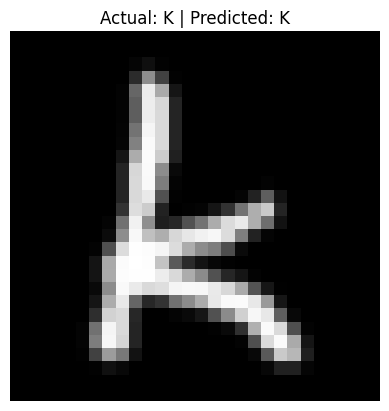

In [ ]:
import matplotlib.pyplot as plt

# pick sample
index = 10

img = X_test[index]
true_label = np.argmax(y_test[index])

# predict
pred = np.argmax(model.predict(img.reshape(1,28,28,1)))

# convert to letter
def label_to_char(label):
    return chr(label + ord('A'))

plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Actual: {label_to_char(true_label)} | Predicted: {label_to_char(pred)}")
plt.axis('off')
plt.show()

In [ ]:
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.utils import to_categorical

# Load EMNIST letters
ds_train, ds_test = tfds.load('emnist/letters', split=['train','test'], as_supervised=True)

def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = convert(ds_train)
X_test, y_test = convert(ds_test)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Fix rotation
X_train = np.rot90(X_train, k=1, axes=(1,2))
X_train = np.flip(X_train, axis=1)

X_test = np.rot90(X_test, k=1, axes=(1,2))
X_test = np.flip(X_test, axis=1)

# Flatten for MLP
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Fix labels
y_train = y_train - 1
y_test = y_test - 1

# One-hot
y_train = to_categorical(y_train, 26)
y_test = to_categorical(y_test, 26)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.W0MQCL_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.W0MQCL_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

lenet = Sequential([
    Conv2D(6, (5,5), activation='relu', input_shape=(28,28,1)),
    AveragePooling2D(pool_size=(2,2)),

    Conv2D(16, (5,5), activation='relu'),
    AveragePooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(120, activation='relu'),
    Dense(84, activation='relu'),
    Dense(26, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.layers import MaxPooling2D, Dropout

alexnet = Sequential([
    Conv2D(96, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(384, (3,3), activation='relu'),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(26, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
zfnet = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(26, activation='softmax')
])

In [ ]:
vgg = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(26, activation='softmax')
])

In [ ]:
from tensorflow.keras.optimizers import Adam

for model in [lenet, alexnet, zfnet, vgg]:
    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_test, y_test)
    )

Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 784), dtype=float32) with name 'keras_tensor' and path ''. Expected shape (None, 28, 28, 1), but input has incompatible shape (None, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 784), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# =========================
# 1. LOAD EMNIST
# =========================
ds_train, ds_test = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True
)

def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = convert(ds_train)
X_test, y_test = convert(ds_test)

# =========================
# 2. PREPROCESS
# =========================
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Fix EMNIST rotation
X_train = np.rot90(X_train, k=1, axes=(1,2))
X_train = np.flip(X_train, axis=1)

X_test = np.rot90(X_test, k=1, axes=(1,2))
X_test = np.flip(X_test, axis=1)

# Reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Fix labels (1–26 → 0–25)
y_train = y_train - 1
y_test = y_test - 1

# One-hot
y_train = to_categorical(y_train, 26)
y_test = to_categorical(y_test, 26)

# =========================
# 3. MODELS
# =========================

# 🔹 LeNet
def build_lenet():
    return Sequential([
        Conv2D(6, (5,5), activation='relu', input_shape=(28,28,1)),
        AveragePooling2D(pool_size=(2,2)),   # FIXED

        Conv2D(16, (5,5), activation='relu'),
        AveragePooling2D(pool_size=(2,2)),   # FIXED

        Flatten(),
        Dense(120, activation='relu'),
        Dense(84, activation='relu'),
        Dense(26, activation='softmax')
    ])

# 🔹 AlexNet (simplified)
def build_alexnet():
    return Sequential([
        Conv2D(96, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D(),
        Conv2D(256, (3,3), activation='relu'),
        MaxPooling2D(),
        Conv2D(384, (3,3), activation='relu'),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(26, activation='softmax')
    ])

# 🔹 ZFNet
def build_zfnet():
    return Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D(),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(26, activation='softmax')
    ])

# 🔹 VGG-style
def build_vgg():
    return Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(26, activation='softmax')
    ])

# =========================
# 4. TRAIN ALL MODELS
# =========================
models = {
    "LeNet": build_lenet(),
    "AlexNet": build_alexnet(),
    "ZFNet": build_zfnet(),
    "VGG": build_vgg()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_test, y_test),
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = acc

# =========================
# 5. FINAL RESULTS
# =========================
print("\nFinal Accuracy Comparison:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Training LeNet...
Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7580 - loss: 0.7902 - val_accuracy: 0.8457 - val_loss: 0.4865
Epoch 2/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8809 - loss: 0.3674 - val_accuracy: 0.8761 - val_loss: 0.3701
Epoch 3/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9020 - loss: 0.2976 - val_accuracy: 0.8820 - val_loss: 0.3541
Epoch 4/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9122 - loss: 0.2621 - val_accuracy: 0.8953 - val_loss: 0.3059
Epoch 5/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9190 - loss: 0.2384 - val_accuracy: 0.8939 - val_loss: 0.3243

Training AlexNet...
Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8287 - loss: 0.5577 - val_accuracy: 0.9068 - val_loss: 0.2729
Epoch 2/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9163 - loss: 0.2568 - val_accuracy: 0.9173 - val_loss: 0.2340
Epoch 3/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, concatenate, Input, Flatten, Dense
from tensorflow.keras.models import Model

def inception_module(x):
    # 1x1 conv
    path1 = Conv2D(32, (1,1), activation='relu', padding='same')(x)

    # 3x3 conv
    path2 = Conv2D(32, (1,1), activation='relu', padding='same')(x)
    path2 = Conv2D(32, (3,3), activation='relu', padding='same')(path2)

    # 5x5 conv
    path3 = Conv2D(32, (1,1), activation='relu', padding='same')(x)
    path3 = Conv2D(32, (5,5), activation='relu', padding='same')(path3)

    # pooling
    path4 = MaxPooling2D((3,3), strides=1, padding='same')(x)
    path4 = Conv2D(32, (1,1), activation='relu', padding='same')(path4)

    return concatenate([path1, path2, path3, path4])

def build_inception():
    inputs = Input(shape=(28,28,1))

    x = Conv2D(32, (3,3), activation='relu')(inputs)
    x = inception_module(x)
    x = MaxPooling2D((2,2))(x)

    x = inception_module(x)
    x = Flatten()(x)

    outputs = Dense(26, activation='softmax')(x)

    return Model(inputs, outputs)

In [ ]:
from tensorflow.keras.layers import Add

def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = Conv2D(filters, (3,3), padding='same')(x)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x

def build_resnet():
    inputs = Input(shape=(28,28,1))

    x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = residual_block(x, 32)
    x = MaxPooling2D((2,2))(x)

    x = residual_block(x, 32)
    x = Flatten()(x)

    outputs = Dense(26, activation='softmax')(x)

    return Model(inputs, outputs)

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

inception_model = build_inception()
resnet_model = build_resnet()

for name, model in [("Inception", inception_model), ("ResNet", resnet_model)]:
    print(f"\nTraining {name}...")

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_test, y_test)
    )


Training Inception...
Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8783 - loss: 0.3875 - val_accuracy: 0.9090 - val_loss: 0.2790
Epoch 2/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9338 - loss: 0.1979 - val_accuracy: 0.9184 - val_loss: 0.2477
Epoch 3/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9470 - loss: 0.1517 - val_accuracy: 0.9193 - val_loss: 0.2454
Epoch 4/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9551 - loss: 0.1208 - val_accuracy: 0.9182 - val_loss: 0.2509
Epoch 5/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9626 - loss: 0.0976 - val_accuracy: 0.9190 - val_loss: 0.2528

Training ResNet...
Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8599 - loss: 0.4525 - val_accuracy: 0.8997 - val_loss: 0.3046
Epoch 2/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9265 - loss: 0.2207 - val_accuracy: 0.9207 - val_loss: 0.2427
Epoch 3/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 8s

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


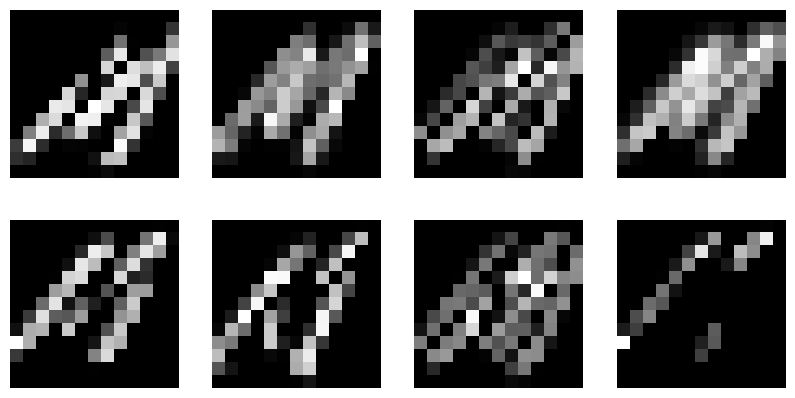

In [ ]:
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras.models import Model

# Load EMNIST
ds_train, ds_test = tfds.load('emnist/letters', split=['train','test'], as_supervised=True)

def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = convert(ds_train)
X_test, y_test = convert(ds_test)

# Normalize
X_test = X_test / 255.0

# Fix rotation
X_test = np.rot90(X_test, k=1, axes=(1,2))
X_test = np.flip(X_test, axis=1)

# Reshape
X_test = X_test.reshape(-1,28,28,1)

# CNN model
inputs = Input(shape=(28,28,1))
x = Conv2D(8, (3,3), activation='relu')(inputs)
pool = MaxPooling2D((2,2))(x)

model = Model(inputs, pool)

# Pick sample
img = X_test[0].reshape(1,28,28,1)

# Feature maps
feature_maps = model.predict(img)

# Plot
plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.axis('off')
plt.show()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.WEB85H_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.WEB85H_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


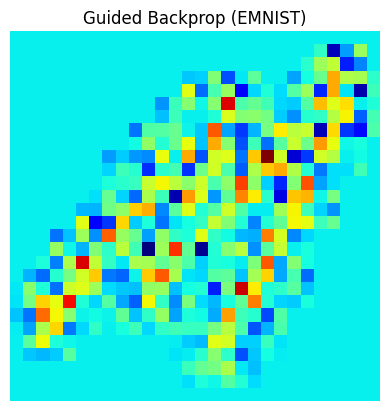

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds

# Load EMNIST (necessary for X_test)
ds_train, ds_test = tfds.load('emnist/letters', split=['train','test'], as_supervised=True)

def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

# We only need X_test for this cell
_, _ = convert(ds_train) # Dummy assignment for X_train, y_train if not needed elsewhere
X_test, _ = convert(ds_test)

# Normalize
X_test = X_test / 255.0

# Fix rotation
X_test = np.rot90(X_test, k=1, axes=(1,2))
X_test = np.flip(X_test, axis=1)

# Reshape for CNN
X_test = X_test.reshape(-1,28,28,1)

# Custom Guided ReLU Layer
class GuidedReLU(Layer):
    def __init__(self, **kwargs):
        super(GuidedReLU, self).__init__(**kwargs)

    @tf.custom_gradient
    def call_guided_relu(self, x):
        def grad(dy):
            return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
        return tf.nn.relu(x), grad

    def call(self, inputs):
        return self.call_guided_relu(inputs)

# Build model
inputs = tf.keras.Input(shape=(28,28,1))
x = Conv2D(8, (3,3))(inputs)
x = GuidedReLU()(x) # Use the custom layer
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(26)(x)
outputs = tf.keras.layers.Softmax()(x)

model = tf.keras.Model(inputs, outputs)

# Pick image
img = tf.convert_to_tensor(X_test[0].reshape(1,28,28,1), dtype=tf.float32)

# Forward + gradient
with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    # Assuming y_test exists and is one-hot encoded, to get class_idx
    # If y_test is not guaranteed to be in scope, we can get the max prediction directly.
    class_idx = tf.argmax(preds[0]) # Get the predicted class index
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img).numpy()[0]

# Plot
plt.imshow(grads.reshape(28,28), cmap='jet')
plt.title("Guided Backprop (EMNIST)")
plt.axis('off')
plt.show()

In [ ]:
import tensorflow_datasets as tfds
import numpy as np

ds_train, ds_test = tfds.load('emnist/letters', split=['train','test'], as_supervised=True)

def convert(ds):
    X, y = [], []
    for img, label in tfds.as_numpy(ds):
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

X_train, _ = convert(ds_train)
X_test, _ = convert(ds_test)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Fix rotation
X_train = np.rot90(X_train, k=1, axes=(1,2))
X_train = np.flip(X_train, axis=1)

X_test = np.rot90(X_test, k=1, axes=(1,2))
X_test = np.flip(X_test, axis=1)

# Flatten
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.Y7LXDK_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.Y7LXDK_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_img = Input(shape=(784,))
encoded = Dense(32, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

under_ae = Model(input_img, decoded)
under_ae.compile(optimizer='adam', loss='mse')

under_ae.fit(X_train, X_train, epochs=5, batch_size=256, validation_data=(X_test, X_test))

Epoch 1/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0672 - val_loss: 0.0376
Epoch 2/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0296 - val_loss: 0.0238
Epoch 3/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0212 - val_loss: 0.0189
Epoch 4/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0179 - val_loss: 0.0168
Epoch 5/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0160 - val_loss: 0.0149


In [ ]:
encoded = Dense(1024, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

over_ae = Model(input_img, decoded)
over_ae.compile(optimizer='adam', loss='mse')

over_ae.fit(X_train, X_train, epochs=5, batch_size=256)

Epoch 1/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0214
Epoch 2/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0051
Epoch 3/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037
Epoch 4/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0031
Epoch 5/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028


In [ ]:
from tensorflow.keras.regularizers import l1

encoded = Dense(128, activation='relu', activity_regularizer=l1(1e-4))(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

reg_ae = Model(input_img, decoded)
reg_ae.compile(optimizer='adam', loss='mse')
reg_ae.fit(X_train, X_train, epochs=5)

Epoch 1/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.1133
Epoch 2/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0845
Epoch 3/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0801
Epoch 4/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0783
Epoch 5/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0778


In [ ]:
noise_factor = 0.3

X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(size=X_test.shape)

encoded = Dense(128, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

denoise_ae = Model(input_img, decoded)
denoise_ae.compile(optimizer='adam', loss='mse')

denoise_ae.fit(X_train_noisy, X_train, epochs=5)

Epoch 1/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0188
Epoch 2/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0091
Epoch 3/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0085
Epoch 4/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0083
Epoch 5/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0082


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=32)
X_pca = pca.fit_transform(X_train)
X_reconstructed = pca.inverse_transform(X_pca)

In [ ]:
from tensorflow.keras.regularizers import l1

encoded = Dense(128, activation='relu', activity_regularizer=l1(1e-5))(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

sparse_ae = Model(input_img, decoded)
sparse_ae.compile(optimizer='adam', loss='mse')

sparse_ae.fit(X_train, X_train, epochs=5)

Epoch 1/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0347
Epoch 2/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0198
Epoch 3/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0164
Epoch 4/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0146
Epoch 5/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0135


In [ ]:
import tensorflow as tf

class ContractiveAE(Model):
    def __init__(self):
        super().__init__()
        self.encoder = Dense(128, activation='relu')
        self.decoder = Dense(784, activation='sigmoid')

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = ContractiveAE()
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, X_train, epochs=5)

Epoch 1/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0137
Epoch 2/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0033
Epoch 3/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0026
Epoch 4/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0023
Epoch 5/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0022
